1.Импорт

In [1]:
import mne
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
import pywt

# 设置 matplotlib 在 Jupyter 中内联显示图表
%matplotlib inline
# 设置全局图表大小和清晰度
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100

Основная задача заключалась в инициализации вычислительной среды. `mne` — это основная библиотека для обработки данных ЭЭГ, отвечающая за чтение и анализ формата EDF; `scipy.signal` предоставляет классические алгоритмы обработки сигналов (такие как фильтры Баттерворта и кратковременные преобразования Фурье); а `pywt` — ключевой инструмент для вейвлет-анализа. Предварительная настройка глобальных параметров matplotlib гарантирует, что все последующие медицинские карты будут отображаться согласованно и четко.

2.Парсинг CSV и извлечение времени начала и конца приступа

In [2]:
# 1. 读取标注 CSV 文件
csv_file = 'annotations_2017_C.csv'
df = pd.read_csv(csv_file)

# 2. 锁定 eeg17.edf 对应的列（列名为字符串 '17'）
target_column = '17' 

# 提取 eeg17 的数据，丢弃尾部的 NaN (空值) 并转为数组
event_data = df[target_column].dropna().values 

print(f"В eeg17.edf всего {len(event_data)} точек аннотации.")
print(f"Из них меток приступа (1): {event_data.sum()} 次。\n")

# 3. 寻找状态切换点 (0 变 1，或 1 变 0)
diffs = np.diff(event_data)

# 找到开始和结束的索引 (+1 修正差值偏移)
start_indices = np.where(diffs == 1)[0] + 1
end_indices = np.where(diffs == -1)[0] + 1

# 处理边界情况 (一开始就发作，或到结束还在发作)
if event_data[0] == 1:
    start_indices = np.insert(start_indices, 0, 0)
if event_data[-1] == 1:
    end_indices = np.append(end_indices, len(event_data) - 1)

# 4. 计算发作起止时间
# 假设标注频率为 1Hz（即 1 行 = 1 秒），您可以根据需要修改
sfreq_annotation = 1.0  

print("-" * 40)
seizure_times = []
for start, end in zip(start_indices, end_indices):
    t_start = start / sfreq_annotation
    t_end = end / sfreq_annotation
    duration = t_end - t_start
    
    seizure_times.append((t_start, t_end))
    print(f"Начало приступа: {t_start:>6.1f} с | Конец приступа: {t_end:>6.1f} с | Длительность: {duration:>4.1f} с")
print("-" * 40)

# 如果检测到发作，将第一次发作的时间赋值给后续分析使用的变量
if seizure_times:
    tmin = seizure_times[0][0]
    tmax = seizure_times[0][1]
    print(f"\nАвтоматически задано временное окно для анализа: tmin = {tmin}, tmax = {tmax}")
else:
    print("\nПриступ не обнаружен.")
    # 如果没有发作，给个默认值以便后续代码不报错，您可以手动修改
    tmin, tmax = 0, 10

В eeg17.edf всего 5493 точек аннотации.
Из них меток приступа (1): 60.0 次。

----------------------------------------
Начало приступа: 2900.0 с | Конец приступа: 2940.0 с | Длительность: 40.0 с
Начало приступа: 2983.0 с | Конец приступа: 2992.0 с | Длительность:  9.0 с
Начало приступа: 3061.0 с | Конец приступа: 3072.0 с | Длительность: 11.0 с
----------------------------------------

Автоматически задано временное окно для анализа: tmin = 2900.0, tmax = 2940.0


3.Загрузка файла EDF и извлечение фрагмента приступа

In [3]:
# 读取 EDF 文件
edf_file = 'eeg17.edf'
# preload=True 表示将数据载入内存以便后续处理
raw = mne.io.read_raw_edf(edf_file, preload=True)

# 获取采样率
sfreq = raw.info['sfreq']
print(f"Частота дискретизации ЭЭГ: {sfreq} Гц")
print(f"Общее количество каналов: {len(raw.ch_names)}")

# 截取癫痫发作期间的数据
# 注意：这会修改 raw 对象本身。如果后续还要用完整的 raw，请先 raw.copy()
raw_seizure = raw.copy().crop(tmin=tmin, tmax=tmax)
print(f"Фрагмент приступа успешно извлечен: от {tmin} с до {tmax} с!")

Extracting EDF parameters from C:\Users\29281\jupyter\研二下周三实验\lab3\eeg17.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...


C:\Users\29281\AppData\Local\Temp\ipykernel_5412\1799253399.py:4: RuntimeWarning: Channels contain different highpass filters. Highest filter setting will be stored.
  raw = mne.io.read_raw_edf(edf_file, preload=True)
C:\Users\29281\AppData\Local\Temp\ipykernel_5412\1799253399.py:4: RuntimeWarning: Channels contain different lowpass filters. Lowest filter setting will be stored.
  raw = mne.io.read_raw_edf(edf_file, preload=True)


Reading 0 ... 1406207  =      0.000 ...  5492.996 secs...
Частота дискретизации ЭЭГ: 256.0 Гц
Общее количество каналов: 21
Фрагмент приступа успешно извлечен: от 2900.0 с до 2940.0 с!


4.График временной зависимости ЭЭГ в момент приступа

Using matplotlib as 2D backend.


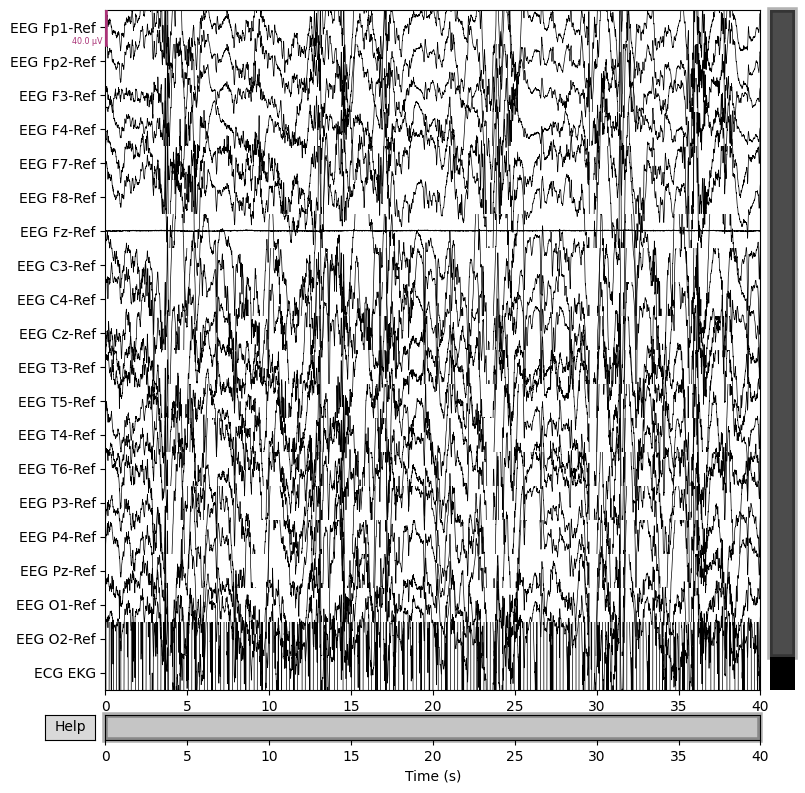

In [4]:
# 绘制发作期间的 EEG 信号
# n_channels=20 表示同时显示 20 个通道
fig = raw_seizure.plot(duration=tmax-tmin, title='EEG During Seizure (eeg17.edf)', n_channels=20, show=False)
plt.show()

Он отображает колебания напряжения в 20 каналах ЭЭГ и 1 канале ЭКГ в различных областях мозга (Fp — префронтальная, F — лобная, C — центральная, T — височная, P — теменная и O — затылочная) в течение 40-секундного временного окна.

5.Усреднение всех каналов и фильтрация низких частот 60 Гц

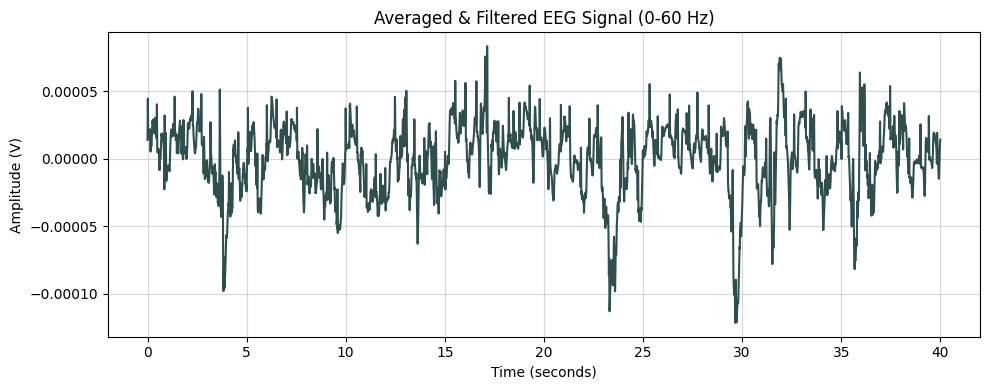

In [5]:
# 提取数据和时间轴
# data 维度: (通道数, 时间点数)
data = raw_seizure.get_data() 
times = raw_seizure.times

# 1. 将所有通道平均为一个通道 (axis=0 代表跨通道求均值)
mean_signal = np.mean(data, axis=0)

# 2. 设计巴特沃斯低通滤波器，截止频率为 60 Hz
nyq = 0.5 * sfreq # 奈奎斯特频率
high_cut = 60.0 / nyq # 归一化截止频率
b, a = signal.butter(N=4, Wn=high_cut, btype='low')

# 使用 filtfilt 进行零相位滤波，防止信号相位发生偏移
filtered_signal = signal.filtfilt(b, a, mean_signal)

# 3. 绘制滤波后的时域信号
plt.figure(figsize=(10, 4))
plt.plot(times, filtered_signal, color='darkslategray')
plt.title('Averaged & Filtered EEG Signal (0-60 Hz)')
plt.xlabel('Time (seconds)')
plt.ylabel('Amplitude (V)')
plt.grid(True, alpha=0.5)
plt.tight_layout()
plt.show()

6.Построение спектрограммы сигнала (STFT)

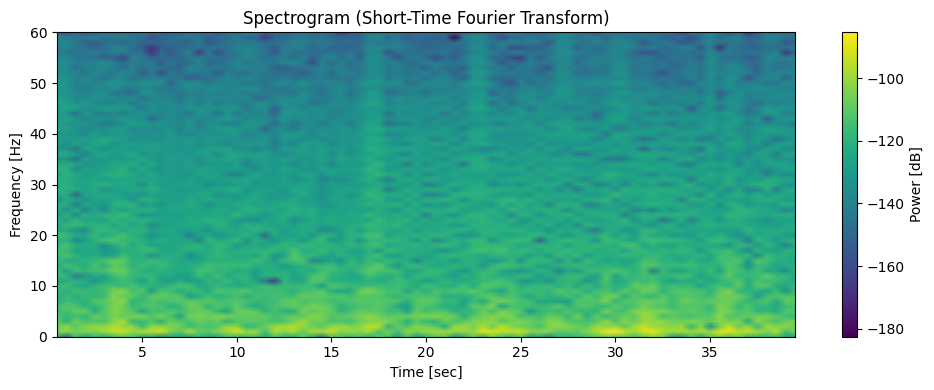

In [6]:
# 计算 STFT 频谱图
# nperseg=256, noverlap=128 是常用经验值，您可以尝试调整以对比效果
f_stft, t_stft, Sxx = signal.spectrogram(filtered_signal, fs=sfreq, nperseg=256, noverlap=128)

# 限制显示频率在 0-60 Hz 内
freq_mask = f_stft <= 60

plt.figure(figsize=(10, 4))
plt.pcolormesh(t_stft, f_stft[freq_mask], 10 * np.log10(Sxx[freq_mask, :]), shading='gouraud', cmap='viridis')
plt.title('Spectrogram (Short-Time Fourier Transform)')
plt.ylabel('Frequency [Hz]')
plt.xlabel('Time [sec]')
plt.colorbar(label='Power [dB]')
plt.tight_layout()
plt.show()

Тепловая карта, построенная с использованием STFT, показывает распределение энергии (мощности) сигнала на частоте (0-60 Гц) во времени (0-40 с). Более светлые цвета (желтый/зеленый) указывают на более высокую энергию, а более темные цвета (темно-синий) — на более низкую.

7.Вейвлет-преобразование (Скейлограмма)

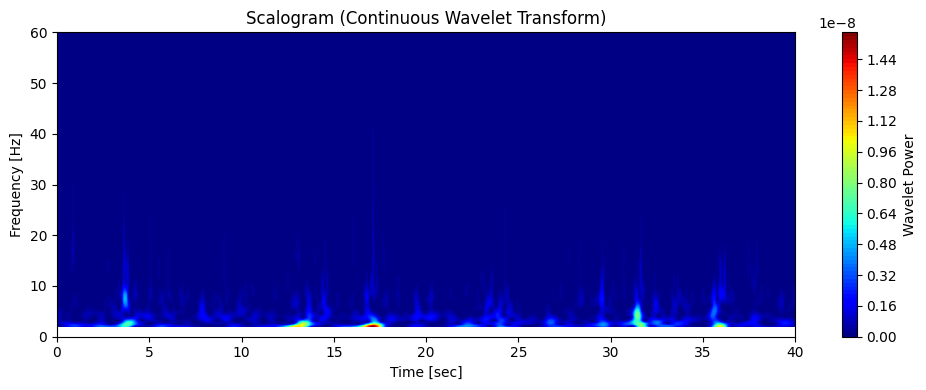

In [7]:
# 定义小波基函数：Complex Morlet (常用于脑电信号)
wavelet = 'cmor1.5-1.0'

# 定义尺度范围
# 尺度 (scale) 和频率成反比。1-128 通常能覆盖大多数相关频率
scales = np.arange(1, 128)

# 计算连续小波变换
coefficients, frequencies = pywt.cwt(filtered_signal, scales, wavelet, sampling_period=1/sfreq)

# 计算小波功率谱（系数绝对值的平方）
power = np.abs(coefficients) ** 2

# 绘制尺度图
plt.figure(figsize=(10, 4))
# 使用 contourf 画出等高线图，levels=100 使颜色过渡更平滑
contour = plt.contourf(times, frequencies, power, levels=100, cmap='jet')
plt.title('Scalogram (Continuous Wavelet Transform)')
plt.ylabel('Frequency [Hz]')
plt.xlabel('Time [sec]')
# 限制纵坐标到我们关心的频率范围 0-60 Hz
plt.ylim(0, 60)
plt.colorbar(contour, label='Wavelet Power')
plt.tight_layout()
plt.show()

Высокоразрешающие частотно-временные диаграммы, построенные с использованием вейвлет-преобразования. Чем более красноватый/желтый цвет, тем выше мощность вейвлет-коэффициентов.